# Task 3 — Energy Consumption Forecasting

## Objective
Forecast building-level energy consumption and compare multiple forecasting approaches:

1. Prophet
2. SARIMA / ARIMA family
3. XGBoost
4. LSTM
5. Temporal Fusion Transformer (TFT) — not implemented in this notebook

Models are evaluated using **MAE, RMSE and MAPE**. Two evaluation views are used:

- a **21-day chronological holdout** for longer unseen-period performance
- an **exact 24-hour recursive forecast** to directly match the challenge requirement of predicting the next 24 hours

> **Dataset note:** The provided synthetic generator creates an Energy Meter for each building. The notebook therefore uses the Energy Meter's `power_consumption` as the building-level energy target rather than summing all asset rows, which would double-count the building meter.

In [8]:
# 1. Imports and configuration

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

FORECAST_HORIZON = 96       # 24 hours at 15-minute intervals
FREQ = "15min"

# Find data/raw from either the notebook folder or project root
possible_dirs = [Path("../data/raw"), Path("data/raw")]
DATA_DIR = next(
    (p for p in possible_dirs if (p / "sensor_telemetry.csv").exists()),
    None
)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find data/raw/sensor_telemetry.csv. "
        "Run the data-generation script from the project root first."
    )

telemetry = pd.read_csv(DATA_DIR / "sensor_telemetry.csv")
metadata = pd.read_csv(DATA_DIR / "asset_metadata.csv")

telemetry["timestamp"] = pd.to_datetime(telemetry["timestamp"])
metadata["installation_date"] = pd.to_datetime(metadata["installation_date"])

telemetry = telemetry.sort_values(["building_id", "timestamp", "asset_id"])

print("Telemetry shape:", telemetry.shape)
print("Metadata shape :", metadata.shape)
display(telemetry.head())

Telemetry shape: (259200, 12)
Metadata shape : (30, 9)


,timestamp,site_id,building_id,asset_id,temperature,humidity,pressure,vibration,power_consumption,occupancy_count,operating_mode,fault_flag
0,2026-01-01,SITE_01,BLDG_01,ASSET_001,18.621,54.498,1.521,0.222,8.971,31,Idle,0
8640,2026-01-01,SITE_01,BLDG_01,ASSET_002,17.672,52.169,0.914,0.110,10.666,31,Idle,0
17280,2026-01-01,SITE_01,BLDG_01,ASSET_003,20.853,53.634,1.090,0.113,15.135,31,Idle,0
25920,2026-01-01,SITE_01,BLDG_01,ASSET_004,19.463,60.645,4.449,0.210,4.201,31,Idle,0
34560,2026-01-01,SITE_01,BLDG_01,ASSET_005,17.415,55.052,1.028,0.073,59.445,31,Heating,0


In [9]:
# Dashboard / artifact output location
# When this notebook is run from the Jupyter Notebook folder,
# ../outputs points to the project-level outputs folder.
OUTPUTS_DIR = (
    Path("../outputs")
    if Path("../outputs").exists()
    else Path("outputs")
)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

## 2. Building-Level Target

The challenge asks for **building-level energy forecasting**.

The dataset contains an `Energy Meter` asset for each building. That meter represents building-level measured energy, so it is used as the target.

Occupancy is duplicated across assets within a building/timestamp, so it is taken once rather than summed.

In [10]:
# Use the building's Energy Meter as the target

energy_meter_ids = metadata.loc[
    metadata["asset_type"].eq("Energy Meter"),
    ["asset_id", "building_id"]
]

building_energy = (
    telemetry
    .merge(energy_meter_ids, on=["asset_id", "building_id"], how="inner")
    [["timestamp", "building_id", "power_consumption"]]
    .rename(columns={"power_consumption": "energy_consumption"})
)

# Add building-level contextual variables once per timestamp
context = (
    telemetry
    .groupby(["timestamp", "building_id"], as_index=False)
    .agg(
        occupancy_count=("occupancy_count", "first"),
        temperature=("temperature", "mean"),
        humidity=("humidity", "mean")
    )
)

building_energy = (
    building_energy
    .merge(context, on=["timestamp", "building_id"], how="left")
    .sort_values(["building_id", "timestamp"])
    .reset_index(drop=True)
)

print("Building-level rows:", len(building_energy))
print("Buildings:", building_energy["building_id"].nunique())
display(building_energy.head())

Building-level rows: 51840
Buildings: 6


,timestamp,building_id,energy_consumption,occupancy_count,temperature,humidity
0,2026-01-01 00:00:00,BLDG_01,59.445,31,18.8048,55.1996
1,2026-01-01 00:15:00,BLDG_01,38.095,43,19.3128,50.4400
2,2026-01-01 00:30:00,BLDG_01,34.187,35,19.0330,52.3564
3,2026-01-01 00:45:00,BLDG_01,35.252,40,19.9302,53.8660
4,2026-01-01 01:00:00,BLDG_01,33.764,25,19.6870,54.8000


## 3. Basic Time-Series EDA

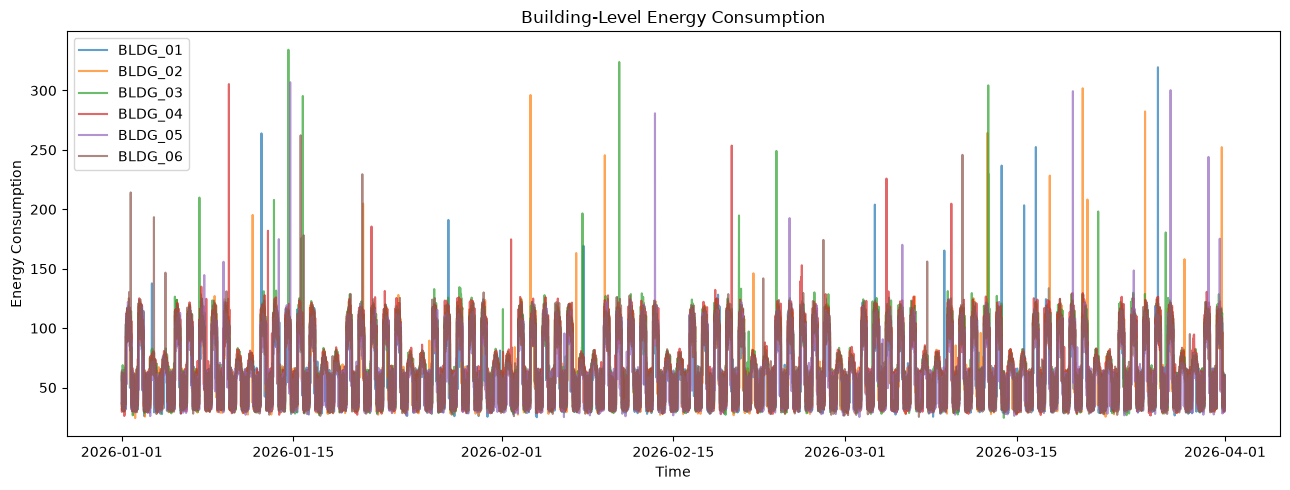

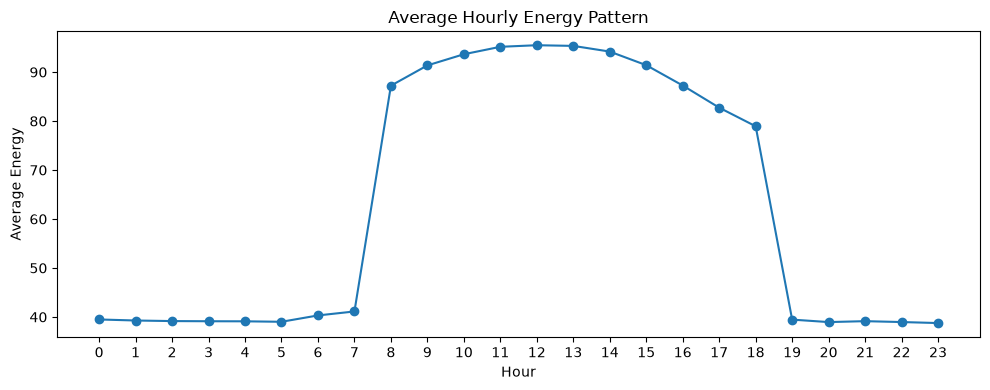

In [11]:
# Energy pattern by building

plt.figure(figsize=(13, 5))

for building in building_energy["building_id"].unique():
    temp = building_energy[building_energy["building_id"] == building]
    plt.plot(
        temp["timestamp"],
        temp["energy_consumption"],
        label=building,
        alpha=0.7
    )

plt.title("Building-Level Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Energy Consumption")
plt.legend()
plt.tight_layout()
plt.show()

# Average hourly pattern
building_energy["hour"] = building_energy["timestamp"].dt.hour

hourly_pattern = (
    building_energy
    .groupby("hour")["energy_consumption"]
    .mean()
)

plt.figure(figsize=(10, 4))
plt.plot(hourly_pattern.index, hourly_pattern.values, marker="o")
plt.title("Average Hourly Energy Pattern")
plt.xlabel("Hour")
plt.ylabel("Average Energy")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

## 4. Chronological Train/Test Split

The last 21 days are held out as an unseen test period. No random shuffle is used because this is a forecasting problem.

In [12]:
split_date = (
    building_energy["timestamp"].max() - pd.Timedelta(days=21)
)

train = building_energy[
    building_energy["timestamp"] < split_date
].copy()

test = building_energy[
    building_energy["timestamp"] >= split_date
].copy()

print("Train:", train.shape)
print("Test :", test.shape)
print("Train:", train["timestamp"].min(), "to", train["timestamp"].max())
print("Test :", test["timestamp"].min(), "to", test["timestamp"].max())

Train: (39738, 7)
Test : (12102, 7)
Train: 2026-01-01 00:00:00 to 2026-03-10 23:30:00
Test : 2026-03-10 23:45:00 to 2026-03-31 23:45:00


In [13]:
# Common evaluation metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    mask = np.abs(actual) > 1e-8
    mape = np.mean(
        np.abs((actual[mask] - predicted[mask]) / actual[mask])
    ) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

def plot_forecast(actual_df, title):
    plt.figure(figsize=(13, 5))
    plt.plot(
        actual_df["timestamp"],
        actual_df["actual"],
        label="Actual"
    )
    plt.plot(
        actual_df["timestamp"],
        actual_df["predicted"],
        label="Forecast"
    )
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Energy Consumption")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 5. Prophet

Prophet models trend and seasonality directly. It is useful as a strong classical forecasting benchmark for daily and weekly energy patterns.

In [14]:
# Install once if required:
# %pip install prophet

from prophet import Prophet

prophet_results = []
prophet_predictions = []

for building in building_energy["building_id"].unique():

    train_b = train[
        train["building_id"] == building
    ][["timestamp", "energy_consumption"]].rename(
        columns={"timestamp": "ds", "energy_consumption": "y"}
    )

    test_b = test[
        test["building_id"] == building
    ][["timestamp", "energy_consumption"]].copy()

    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False
    )

    model.fit(train_b)

    future = test_b[["timestamp"]].rename(
        columns={"timestamp": "ds"}
    )

    forecast = model.predict(future)

    pred = forecast["yhat"].values

    metrics = calculate_metrics(
        test_b["energy_consumption"].values,
        pred
    )
    metrics["Model"] = "Prophet"
    metrics["Building"] = building
    prophet_results.append(metrics)

    prophet_predictions.append(pd.DataFrame({
        "timestamp": test_b["timestamp"].values,
        "building_id": building,
        "actual": test_b["energy_consumption"].values,
        "predicted": pred
    }))

prophet_results = pd.DataFrame(prophet_results)
prophet_predictions = pd.concat(prophet_predictions, ignore_index=True)

display(prophet_results)
display(prophet_results.groupby("Model")[["MAE", "RMSE", "MAPE"]].mean())

05:57:33 - cmdstanpy - INFO - Chain [1] start processing
05:57:34 - cmdstanpy - INFO - Chain [1] done processing
05:57:37 - cmdstanpy - INFO - Chain [1] start processing
05:57:37 - cmdstanpy - INFO - Chain [1] done processing
05:57:40 - cmdstanpy - INFO - Chain [1] start processing
05:57:42 - cmdstanpy - INFO - Chain [1] done processing
05:57:44 - cmdstanpy - INFO - Chain [1] start processing
05:57:46 - cmdstanpy - INFO - Chain [1] done processing
05:57:49 - cmdstanpy - INFO - Chain [1] start processing
05:57:50 - cmdstanpy - INFO - Chain [1] done processing
05:57:54 - cmdstanpy - INFO - Chain [1] start processing
05:57:54 - cmdstanpy - INFO - Chain [1] done processing


,MAE,RMSE,MAPE,Model,Building
0,12.378116,16.671523,24.179918,Prophet,BLDG_01
1,12.204209,17.518341,21.945947,Prophet,BLDG_02
2,11.536645,15.598405,21.114547,Prophet,BLDG_03
3,11.431036,13.959153,21.496085,Prophet,BLDG_04
4,12.299667,16.530772,24.254561,Prophet,BLDG_05
5,10.972879,13.549890,20.584652,Prophet,BLDG_06


,MAE,RMSE,MAPE
Model,,,
Prophet,11.803759,15.638014,22.262618


# 6. SARIMA

SARIMA extends ARIMA with seasonal terms. Because the 15-minute seasonal model with period 96 was computationally expensive in the available environment, SARIMA is evaluated at **hourly resolution**, where 24 observations represent one day.

In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd

sarima_results = []
sarima_predictions = []

for building in building_energy["building_id"].unique():

    print(f"Training SARIMA for {building}...")

    # --------------------------------
    # Training data - hourly
    # --------------------------------
    train_b = (
        train[train["building_id"] == building]
        .sort_values("timestamp")
        .set_index("timestamp")["energy_consumption"]
        .resample("1h")
        .mean()
    )

    # --------------------------------
    # Test data - hourly
    # --------------------------------
    test_b = (
        test[test["building_id"] == building]
        .sort_values("timestamp")
        .set_index("timestamp")["energy_consumption"]
        .resample("1h")
        .mean()
    )

    # --------------------------------
    # Handle missing values
    # --------------------------------
    train_b = train_b.interpolate(method="time").ffill().bfill()
    test_b = test_b.interpolate(method="time").ffill().bfill()

    # --------------------------------
    # SARIMA
    # --------------------------------
    model = SARIMAX(
        train_b,
        order=(1, 1, 1),
        seasonal_order=(1, 0, 1, 24),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted = model.fit(
        disp=False,
        maxiter=100
    )

    # --------------------------------
    # Forecast
    # --------------------------------
    prediction = fitted.forecast(
        steps=len(test_b)
    )

    # --------------------------------
    # Evaluation
    # --------------------------------
    metrics = calculate_metrics(
        test_b.values,
        prediction.values
    )

    metrics["Model"] = "SARIMA"
    metrics["Building"] = building

    sarima_results.append(metrics)

    # --------------------------------
    # Store predictions
    # --------------------------------
    sarima_predictions.append(
        pd.DataFrame({
            "timestamp": test_b.index,
            "building_id": building,
            "actual": test_b.values,
            "predicted": prediction.values
        })
    )

    print(f"Completed {building}")


# --------------------------------
# Combine results
# --------------------------------
sarima_results = pd.DataFrame(sarima_results)

sarima_predictions = pd.concat(
    sarima_predictions,
    ignore_index=True
)


# --------------------------------
# Building-wise results
# --------------------------------
display(sarima_results)


# --------------------------------
# Average performance
# --------------------------------
display(
    sarima_results
    .groupby("Model")[["MAE", "RMSE", "MAPE"]]
    .mean()
)

Training SARIMA for BLDG_01...
Completed BLDG_01
Training SARIMA for BLDG_02...
Completed BLDG_02
Training SARIMA for BLDG_03...
Completed BLDG_03
Training SARIMA for BLDG_04...
Completed BLDG_04
Training SARIMA for BLDG_05...
Completed BLDG_05
Training SARIMA for BLDG_06...
Completed BLDG_06


,MAE,RMSE,MAPE,Model,Building
0,11.818349,17.283615,20.007579,SARIMA,BLDG_01
1,12.343991,17.833252,20.355199,SARIMA,BLDG_02
2,12.053901,18.090027,19.377033,SARIMA,BLDG_03
3,11.767556,17.514686,19.321247,SARIMA,BLDG_04
4,12.427822,17.704357,24.145080,SARIMA,BLDG_05
5,11.911917,16.975251,19.359378,SARIMA,BLDG_06


,MAE,RMSE,MAPE
Model,,,
SARIMA,12.053923,17.566865,20.427586


# 7. XGBoost

XGBoost treats forecasting as a supervised learning problem. The corrected implementation operates at **hourly resolution** and uses:

- calendar features
- previous 1-hour value
- previous 6-hour value
- previous 24-hour value
- previous 7-day value
- rolling historical averages/statistics
- cyclic hour features

The model is trained separately for each building. During forecasting, predictions are recursively fed back into the history, so actual future test values are not used to construct future lag features.

In [16]:
# ============================================================
# XGBOOST — HOURLY RECURSIVE ENERGY FORECASTING
# ============================================================

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd


# ============================================================
# 1. Create hourly building-level energy
# ============================================================

hourly_energy = (
    building_energy
    .copy()
    .sort_values(["building_id", "timestamp"])
)

hourly_energy["timestamp"] = pd.to_datetime(
    hourly_energy["timestamp"]
)

hourly_energy = (
    hourly_energy
    .set_index("timestamp")
    .groupby("building_id")["energy_consumption"]
    .resample("1h")
    .mean()
    .reset_index()
)


# ============================================================
# 2. Train / test split
# ============================================================

xgb_train = hourly_energy[
    hourly_energy["timestamp"] < split_date
].copy()

xgb_test = hourly_energy[
    hourly_energy["timestamp"] >= split_date
].copy()


print("XGBoost training rows:", len(xgb_train))
print("XGBoost test rows:", len(xgb_test))


# ============================================================
# 3. Feature creation function
# ============================================================

def create_xgb_training_features(df):

    df = (
        df
        .copy()
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Calendar features
    # --------------------------------------------------------

    df["hour"] = (
        df["timestamp"].dt.hour
    )

    df["day_of_week"] = (
        df["timestamp"].dt.dayofweek
    )

    df["is_weekend"] = (
        df["day_of_week"] >= 5
    ).astype(int)

    # Cyclic hour encoding

    df["hour_sin"] = np.sin(
        2 * np.pi * df["hour"] / 24
    )

    df["hour_cos"] = np.cos(
        2 * np.pi * df["hour"] / 24
    )

    # --------------------------------------------------------
    # Historical lag features
    # --------------------------------------------------------

    df["lag_1"] = (
        df["energy_consumption"]
        .shift(1)
    )

    df["lag_6"] = (
        df["energy_consumption"]
        .shift(6)
    )

    df["lag_24"] = (
        df["energy_consumption"]
        .shift(24)
    )

    df["lag_168"] = (
        df["energy_consumption"]
        .shift(168)
    )

    # --------------------------------------------------------
    # Rolling features
    # IMPORTANT:
    # shift(1) prevents current target leakage
    # --------------------------------------------------------

    shifted = (
        df["energy_consumption"]
        .shift(1)
    )

    df["rolling_mean_6h"] = (
        shifted
        .rolling(6)
        .mean()
    )

    df["rolling_mean_24h"] = (
        shifted
        .rolling(24)
        .mean()
    )

    df["rolling_std_24h"] = (
        shifted
        .rolling(24)
        .std()
    )

    return df


# ============================================================
# 4. Train and recursively forecast each building
# ============================================================

xgb_results = []
xgb_predictions = []
xgb_models = {}


for building in hourly_energy["building_id"].unique():

    print(
        f"\nProcessing XGBoost for {building}..."
    )

    # --------------------------------------------------------
    # Building-specific train data
    # --------------------------------------------------------

    building_train = (
        xgb_train[
            xgb_train["building_id"] == building
        ]
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    building_test = (
        xgb_test[
            xgb_test["building_id"] == building
        ]
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Create training features
    # --------------------------------------------------------

    train_features = (
        create_xgb_training_features(
            building_train
        )
    )

    feature_columns = [
        "hour",
        "day_of_week",
        "is_weekend",
        "hour_sin",
        "hour_cos",
        "lag_1",
        "lag_6",
        "lag_24",
        "lag_168",
        "rolling_mean_6h",
        "rolling_mean_24h",
        "rolling_std_24h"
    ]

    train_features = (
        train_features
        .dropna(
            subset=feature_columns
            + ["energy_consumption"]
        )
    )

    X_train = train_features[
        feature_columns
    ]

    y_train = train_features[
        "energy_consumption"
    ]

    # --------------------------------------------------------
    # XGBoost model
    # --------------------------------------------------------

    xgb_model = XGBRegressor(

        n_estimators=200,

        max_depth=5,

        learning_rate=0.05,

        subsample=0.8,

        colsample_bytree=0.8,

        objective="reg:squarederror",

        random_state=SEED,

        n_jobs=-1
    )

    xgb_model.fit(
        X_train,
        y_train
    )

    # Keep the building-specific trained model for exact 24-hour evaluation.
    xgb_models[building] = xgb_model

    # --------------------------------------------------------
    # Recursive forecasting
    # --------------------------------------------------------

    history = building_train[
        [
            "timestamp",
            "energy_consumption"
        ]
    ].copy()

    predictions = []

    for _, test_row in building_test.iterrows():

        current_timestamp = (
            test_row["timestamp"]
        )

        # ----------------------------------------------------
        # Build temporary history
        # ----------------------------------------------------

        temp = history.copy()

        temp = temp.sort_values(
            "timestamp"
        ).reset_index(drop=True)

        # ----------------------------------------------------
        # Calendar features
        # ----------------------------------------------------

        current_hour = (
            current_timestamp.hour
        )

        current_day = (
            current_timestamp.dayofweek
        )

        current_is_weekend = int(
            current_day >= 5
        )

        # ----------------------------------------------------
        # Historical features
        # ----------------------------------------------------

        energy_values = (
            temp["energy_consumption"]
            .values
        )

        lag_1 = energy_values[-1]

        lag_6 = energy_values[-6]

        lag_24 = energy_values[-24]

        lag_168 = energy_values[-168]

        rolling_mean_6h = (
            temp["energy_consumption"]
            .tail(6)
            .mean()
        )

        rolling_mean_24h = (
            temp["energy_consumption"]
            .tail(24)
            .mean()
        )

        rolling_std_24h = (
            temp["energy_consumption"]
            .tail(24)
            .std()
        )

        # ----------------------------------------------------
        # Create one prediction row
        # ----------------------------------------------------

        X_current = pd.DataFrame({

            "hour": [
                current_hour
            ],

            "day_of_week": [
                current_day
            ],

            "is_weekend": [
                current_is_weekend
            ],

            "hour_sin": [
                np.sin(
                    2 * np.pi
                    * current_hour
                    / 24
                )
            ],

            "hour_cos": [
                np.cos(
                    2 * np.pi
                    * current_hour
                    / 24
                )
            ],

            "lag_1": [
                lag_1
            ],

            "lag_6": [
                lag_6
            ],

            "lag_24": [
                lag_24
            ],

            "lag_168": [
                lag_168
            ],

            "rolling_mean_6h": [
                rolling_mean_6h
            ],

            "rolling_mean_24h": [
                rolling_mean_24h
            ],

            "rolling_std_24h": [
                rolling_std_24h
            ]
        })

        # ----------------------------------------------------
        # Predict
        # ----------------------------------------------------

        prediction = (
            xgb_model
            .predict(X_current)[0]
        )

        predictions.append(
            prediction
        )

        # ----------------------------------------------------
        # VERY IMPORTANT:
        # Add prediction to history.
        #
        # We DO NOT add the actual test value.
        # ----------------------------------------------------

        history = pd.concat(
            [
                history,

                pd.DataFrame({
                    "timestamp": [
                        current_timestamp
                    ],

                    "energy_consumption": [
                        prediction
                    ]
                })
            ],

            ignore_index=True
        )

    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    actual = (
        building_test[
            "energy_consumption"
        ].values
    )

    predicted = np.array(
        predictions
    )

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    mape = (
        np.mean(
            np.abs(
                (actual - predicted)
                /
                np.maximum(
                    np.abs(actual),
                    1e-6
                )
            )
        )
        * 100
    )

    xgb_results.append({

        "Model": "XGBoost",

        "Building": building,

        "MAE": mae,

        "RMSE": rmse,

        "MAPE": mape
    })

    # --------------------------------------------------------
    # Store predictions
    # --------------------------------------------------------

    xgb_predictions.append(
        pd.DataFrame({

            "timestamp":
                building_test[
                    "timestamp"
                ].values,

            "building_id":
                building,

            "actual":
                actual,

            "predicted":
                predicted
        })
    )

    print(
        f"Completed {building} | "
        f"MAE: {mae:.3f} | "
        f"RMSE: {rmse:.3f} | "
        f"MAPE: {mape:.3f}"
    )


# ============================================================
# 5. Combine results
# ============================================================

xgb_results = pd.DataFrame(
    xgb_results
)

xgb_predictions = pd.concat(
    xgb_predictions,
    ignore_index=True
)


# ============================================================
# 6. Display results
# ============================================================

print("\nXGBoost building-wise results:")

display(
    xgb_results
)


print("\nAverage XGBoost performance:")

display(
    xgb_results[
        ["MAE", "RMSE", "MAPE"]
    ].mean()
)

XGBoost training rows: 9936
XGBoost test rows: 3024

Processing XGBoost for BLDG_01...
Completed BLDG_01 | MAE: 5.196 | RMSE: 8.059 | MAPE: 9.638

Processing XGBoost for BLDG_02...
Completed BLDG_02 | MAE: 5.157 | RMSE: 7.739 | MAPE: 9.207

Processing XGBoost for BLDG_03...
Completed BLDG_03 | MAE: 4.015 | RMSE: 5.892 | MAPE: 7.531

Processing XGBoost for BLDG_04...
Completed BLDG_04 | MAE: 4.120 | RMSE: 5.400 | MAPE: 7.953

Processing XGBoost for BLDG_05...
Completed BLDG_05 | MAE: 4.964 | RMSE: 7.076 | MAPE: 9.396

Processing XGBoost for BLDG_06...
Completed BLDG_06 | MAE: 3.971 | RMSE: 5.056 | MAPE: 7.900

XGBoost building-wise results:


,Model,Building,MAE,RMSE,MAPE
0,XGBoost,BLDG_01,5.196307,8.058834,9.637774
1,XGBoost,BLDG_02,5.156969,7.738534,9.206701
2,XGBoost,BLDG_03,4.014554,5.892038,7.531153
3,XGBoost,BLDG_04,4.120118,5.400086,7.952532
4,XGBoost,BLDG_05,4.964056,7.075723,9.396169
5,XGBoost,BLDG_06,3.970545,5.056342,7.900378



Average XGBoost performance:


MAE     4.570425
RMSE    6.536926
MAPE    8.604118
dtype: float64

# 8. LSTM

The LSTM receives a sequence of historical hourly energy values and learns temporal dependencies.

A **24-step input represents the previous 24 hours at hourly resolution**. The model is trained one-step-ahead and then recursively generates future values.

In [17]:
# ============================================================
# LSTM — HOURLY RECURSIVE ENERGY FORECASTING
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

WINDOW = 24          # Previous 24 hours
EPOCHS = 2           # Reduced because training is expensive
BATCH_SIZE = 256


# ============================================================
# 1. Prepare hourly building-level energy
# ============================================================

hourly_energy = (
    building_energy
    .copy()
    .sort_values(["building_id", "timestamp"])
)

hourly_energy["timestamp"] = pd.to_datetime(
    hourly_energy["timestamp"]
)

hourly_energy = (
    hourly_energy
    .set_index("timestamp")
    .groupby("building_id")["energy_consumption"]
    .resample("1h")
    .mean()
    .reset_index()
)

print("Hourly building energy shape:")
print(hourly_energy.shape)

display(hourly_energy.head())


# ============================================================
# 2. Create sequences
# ============================================================

def create_sequences(values, window=24):

    X, y = [], []

    for i in range(window, len(values)):

        X.append(
            values[i-window:i]
        )

        y.append(
            values[i]
        )

    return (
        np.array(X),
        np.array(y)
    )


# ============================================================
# 3. Results containers
# ============================================================

lstm_results = []
lstm_predictions = []


# ============================================================
# 4. Train one LSTM per building
# ============================================================

for building in hourly_energy["building_id"].unique():

    print(
        f"\nTraining LSTM for {building}..."
    )

    building_df = (
        hourly_energy[
            hourly_energy["building_id"] == building
        ]
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    series = (
        building_df[
            "energy_consumption"
        ]
        .values
    )

    # --------------------------------------------------------
    # Test length
    # --------------------------------------------------------

    test_len = len(
        hourly_energy[
            (hourly_energy["building_id"] == building)
            &
            (
                hourly_energy["timestamp"]
                >= split_date
            )
        ]
    )

    train_series = series[:-test_len]

    test_series = series[-test_len:]

    # --------------------------------------------------------
    # Scaling
    # IMPORTANT:
    # Fit scaler only on training data
    # --------------------------------------------------------

    scaler = MinMaxScaler()

    train_scaled = scaler.fit_transform(
        train_series.reshape(-1, 1)
    )

    # --------------------------------------------------------
    # Create training sequences
    # --------------------------------------------------------

    X_train, y_train = create_sequences(
        train_scaled,
        WINDOW
    )

    X_train = X_train.reshape(
        X_train.shape[0],
        X_train.shape[1],
        1
    )

    # --------------------------------------------------------
    # LSTM model
    # --------------------------------------------------------

    model = Sequential([

        LSTM(
            32,
            input_shape=(WINDOW, 1)
        ),

        Dropout(0.2),

        Dense(
            16,
            activation="relu"
        ),

        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    model.fit(
        X_train,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        verbose=1
    )

    # --------------------------------------------------------
    # Recursive forecasting
    # --------------------------------------------------------

    history = list(
        train_scaled[-WINDOW:].flatten()
    )

    predictions_scaled = []

    for step in range(test_len):

        X_input = np.array(
            history[-WINDOW:],
            dtype=np.float32
        ).reshape(
            1,
            WINDOW,
            1
        )

        next_value = model.predict(
            X_input,
            verbose=0
        )[0, 0]

        predictions_scaled.append(
            next_value
        )

        # IMPORTANT:
        # Use prediction, NOT actual test value
        history.append(
            next_value
        )

    # --------------------------------------------------------
    # Convert predictions back to original scale
    # --------------------------------------------------------

    predictions = scaler.inverse_transform(
        np.array(
            predictions_scaled
        ).reshape(-1, 1)
    ).flatten()

    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    metrics = calculate_metrics(
        test_series,
        predictions
    )

    metrics["Model"] = "LSTM"
    metrics["Building"] = building

    lstm_results.append(
        metrics
    )

    # --------------------------------------------------------
    # Store predictions
    # --------------------------------------------------------

    dates = (
        building_df
        .tail(test_len)
        ["timestamp"]
        .values
    )

    lstm_predictions.append(
        pd.DataFrame({

            "timestamp": dates,

            "building_id": building,

            "actual": test_series,

            "predicted": predictions
        })
    )

    print(
        f"Completed {building} | "
        f"MAE: {metrics['MAE']:.3f} | "
        f"RMSE: {metrics['RMSE']:.3f} | "
        f"MAPE: {metrics['MAPE']:.3f}"
    )


# ============================================================
# 5. Combine results
# ============================================================

lstm_results = pd.DataFrame(
    lstm_results
)

lstm_predictions = pd.concat(
    lstm_predictions,
    ignore_index=True
)


# ============================================================
# 6. Display results
# ============================================================

print("\nBuilding-wise LSTM results:")

display(
    lstm_results
)


print("\nAverage LSTM performance:")

display(
    lstm_results[
        ["MAE", "RMSE", "MAPE"]
    ].mean()
)

Hourly building energy shape:
(12960, 3)


,building_id,timestamp,energy_consumption
0,BLDG_01,2026-01-01 00:00:00,41.74475
1,BLDG_01,2026-01-01 01:00:00,48.17100
2,BLDG_01,2026-01-01 02:00:00,35.57350
3,BLDG_01,2026-01-01 03:00:00,41.25050
4,BLDG_01,2026-01-01 04:00:00,39.85575



Training LSTM for BLDG_01...
Epoch 1/2
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 212ms/step - loss: 0.1480 - val_loss: 0.1165
Epoch 2/2
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.1004 - val_loss: 0.0816
Completed BLDG_01 | MAE: 24.889 | RMSE: 35.880 | MAPE: 30.565

Training LSTM for BLDG_02...
Epoch 1/2
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 336ms/step - loss: 0.0907 - val_loss: 0.0672
Epoch 2/2
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0583 - val_loss: 0.0489
Completed BLDG_02 | MAE: 25.452 | RMSE: 28.066 | MAPE: 48.236

Training LSTM for BLDG_03...
Epoch 1/2
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 286ms/step - loss: 0.0549 - val_loss: 0.0398
Epoch 2/2
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0399 - val_loss: 0.0346
Completed BLDG_03 | MAE: 29.203 | RMSE: 31.426 | MAPE: 58.787

Training LSTM for BLDG_04...
Epoch 1/2
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 189ms/step - loss: 0.1133 - val_loss: 0.0846
Epoch 2/2
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0653 - val_loss: 0.0573
Completed BLDG_04 | MAE: 27.376 | 

,MAE,RMSE,MAPE,Model,Building
0,24.888550,35.880446,30.564785,LSTM,BLDG_01
1,25.451972,28.066207,48.235983,LSTM,BLDG_02
2,29.203042,31.426105,58.787164,LSTM,BLDG_03
3,27.376026,29.866297,48.215045,LSTM,BLDG_04
4,23.597837,26.527613,43.595688,LSTM,BLDG_05
5,28.578628,30.724335,60.006650,LSTM,BLDG_06



Average LSTM performance:


MAE     26.516009
RMSE    30.415167
MAPE    48.234219
dtype: float64

## 10. Model Comparison

Combine the available model results. The notebook currently contains results for Prophet, SARIMA, XGBoost and LSTM. TFT is documented as a possible extension but is not included in the comparison because it was not trained in this environment.

The selection should be based on the actual unseen test results — not on the model name or complexity.

In [18]:
# Combine available model results

result_frames = [
    prophet_results,
    sarima_results,lstm_results,
    xgb_results]

all_results = pd.concat(
    result_frames,
    ignore_index=True
)

model_comparison = (
    all_results
    .groupby("Model")[["MAE", "RMSE", "MAPE"]]
    .mean()
    .sort_values(["RMSE", "MAE", "MAPE"])
)

display(model_comparison)

print(
    "TFT results should be appended after its predictions "
    "are converted to the same actual/predicted format."
)

,MAE,RMSE,MAPE
Model,,,
XGBoost,4.570425,6.536926,8.604118
Prophet,11.803759,15.638014,22.262618
SARIMA,12.053923,17.566865,20.427586
LSTM,26.516009,30.415167,48.234219


TFT results should be appended after its predictions are converted to the same actual/predicted format.


## 11. Model Selection Rule

Use the actual test results.

A practical selection rule is:

- lower MAE = better average absolute error
- lower RMSE = fewer large forecasting errors
- lower MAPE = better percentage accuracy

Use RMSE as the primary criterion because large energy-forecast errors can be operationally important, with MAE and MAPE used as supporting metrics.

In [19]:
best_model = model_comparison.sort_values(
    ["RMSE", "MAE", "MAPE"]
).index[0]

print("Selected model:", best_model)

Selected model: XGBoost


# 12. Forecast Visualization

Plot actual versus predicted energy for each building and the selected model.

For the final submission, include:
- one combined model-comparison table
- one forecast plot per building
- a short explanation of the selected model
- key operational insights

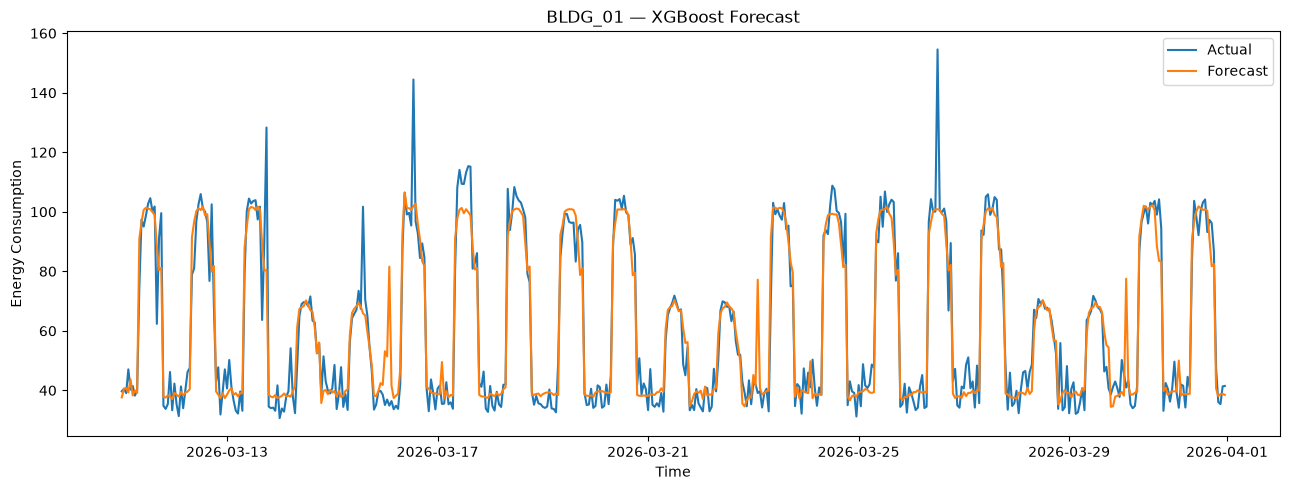

Use the prediction dataframe corresponding to the selected model.


In [20]:
# Example: plot one model's predictions

# Change this dataframe to the selected model's prediction dataframe.
# Example:
#
plot_forecast(
    xgb_predictions[
        xgb_predictions["building_id"] == "BLDG_01"
    ],
    "BLDG_01 — XGBoost Forecast"
)

print("Use the prediction dataframe corresponding to the selected model.")

# 13. Exact 24-Hour Evaluation — XGBoost

The challenge specifically asks for prediction of the **next 24 hours**. The 21-day holdout above is useful for longer unseen-period evaluation, but it does not by itself represent a strict 24-hour forecast.

For this evaluation:

- the forecast origin is the first hourly timestamp of the XGBoost test period
- only the previous training history is available to the model
- exactly **24 future hourly values** are predicted
- predictions are generated **recursively**
- each prediction is added back to history before generating the next hour
- actual future energy values are used only for evaluation, never as future lag inputs

In [21]:
# Exact 24-hour recursive forecast helper

def forecast_next_24h_xgb(model, history_df, horizon=24):
    """Recursively forecast the next `horizon` hourly energy values."""

    history = history_df.copy()
    history["timestamp"] = pd.to_datetime(history["timestamp"])
    history = history.sort_values("timestamp").reset_index(drop=True)

    predictions = []
    prediction_times = []

    required_history = 168
    if len(history) < required_history:
        raise ValueError(
            f"At least {required_history} historical hourly observations are required."
        )

    for _ in range(horizon):
        next_timestamp = (
            history["timestamp"].iloc[-1] + pd.Timedelta(hours=1)
        )

        energy_values = history["energy_consumption"].to_numpy()

        current_hour = next_timestamp.hour
        current_day = next_timestamp.dayofweek

        X_current = pd.DataFrame({
            "hour": [current_hour],
            "day_of_week": [current_day],
            "is_weekend": [int(current_day >= 5)],
            "hour_sin": [np.sin(2 * np.pi * current_hour / 24)],
            "hour_cos": [np.cos(2 * np.pi * current_hour / 24)],
            "lag_1": [energy_values[-1]],
            "lag_6": [energy_values[-6]],
            "lag_24": [energy_values[-24]],
            "lag_168": [energy_values[-168]],
            "rolling_mean_6h": [history["energy_consumption"].tail(6).mean()],
            "rolling_mean_24h": [history["energy_consumption"].tail(24).mean()],
            "rolling_std_24h": [history["energy_consumption"].tail(24).std()]
        })

        prediction = float(model.predict(X_current)[0])

        predictions.append(prediction)
        prediction_times.append(next_timestamp)

        # Recursive step: use the prediction, not the actual future value.
        history = pd.concat(
            [
                history,
                pd.DataFrame({
                    "timestamp": [next_timestamp],
                    "energy_consumption": [prediction]
                })
            ],
            ignore_index=True
        )

    return pd.DataFrame({
        "timestamp": prediction_times,
        "predicted": predictions
    })

## 13.1 Run the exact 24-hour evaluation

The forecast origin is chosen as the first hourly timestamp in the XGBoost test period. This gives a clean unseen 24-hour window immediately after the training period.

In [22]:
# Exact 24-hour forecast origin

exact_24h_origin = xgb_test["timestamp"].min()

print("Exact 24-hour forecast origin:", exact_24h_origin)
print("Forecast end:", exact_24h_origin + pd.Timedelta(hours=23))

Exact 24-hour forecast origin: 2026-03-11 00:00:00
Forecast end: 2026-03-11 23:00:00


In [23]:
# Evaluate exactly 24 hourly predictions for every building

exact_24h_results = []
exact_24h_predictions = []

for building in sorted(hourly_energy["building_id"].unique()):

    model = xgb_models[building]

    building_history = (
        xgb_train[xgb_train["building_id"] == building]
        [["timestamp", "energy_consumption"]]
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    building_actual = (
        xgb_test[xgb_test["building_id"] == building]
        [["timestamp", "energy_consumption"]]
        .sort_values("timestamp")
        .head(24)
        .reset_index(drop=True)
    )

    if len(building_actual) != 24:
        raise ValueError(
            f"{building}: expected 24 actual observations, "
            f"found {len(building_actual)}."
        )

    forecast = forecast_next_24h_xgb(
        model=model,
        history_df=building_history,
        horizon=24
    )

    comparison = building_actual.rename(
        columns={"energy_consumption": "actual"}
    ).merge(
        forecast,
        on="timestamp",
        how="inner"
    )

    if len(comparison) != 24:
        raise ValueError(
            f"{building}: expected 24 matched forecast points, "
            f"found {len(comparison)}."
        )

    metrics = calculate_metrics(
        comparison["actual"].values,
        comparison["predicted"].values
    )

    exact_24h_results.append({
        "Model": "XGBoost",
        "Building": building,
        **metrics
    })

    comparison["building_id"] = building
    exact_24h_predictions.append(comparison)

exact_24h_results = pd.DataFrame(exact_24h_results)
exact_24h_predictions = pd.concat(
    exact_24h_predictions,
    ignore_index=True
)

print("Exact 24-hour evaluation results:")
display(exact_24h_results)

Exact 24-hour evaluation results:


,Model,Building,MAE,RMSE,MAPE
0,XGBoost,BLDG_01,5.497271,8.365831,9.099831
1,XGBoost,BLDG_02,3.967110,5.206630,7.501486
2,XGBoost,BLDG_03,3.561289,4.276459,6.284842
3,XGBoost,BLDG_04,4.892024,6.101482,8.892289
4,XGBoost,BLDG_05,5.093539,6.230347,8.800095
5,XGBoost,BLDG_06,4.229824,5.063161,8.222966


## 13.2 Overall exact 24-hour performance

The overall values below are the mean of the six building-level 24-hour evaluations.

In [24]:
overall_exact_24h = (
    exact_24h_results
    [["MAE", "RMSE", "MAPE"]]
    .mean()
)

print("=" * 55)
print("Overall Exact 24-Hour XGBoost Performance")
print("=" * 55)
print(f"MAE  : {overall_exact_24h['MAE']:.3f}")
print(f"RMSE : {overall_exact_24h['RMSE']:.3f}")
print(f"MAPE : {overall_exact_24h['MAPE']:.2f}%")

Overall Exact 24-Hour XGBoost Performance
MAE  : 4.540
RMSE : 5.874
MAPE : 8.13%


## 13.3 Actual vs predicted — exact 24 hours

The plot shows the strict 24-hour forecast window for each building. The model generates the 24 points recursively without seeing the actual future energy values.

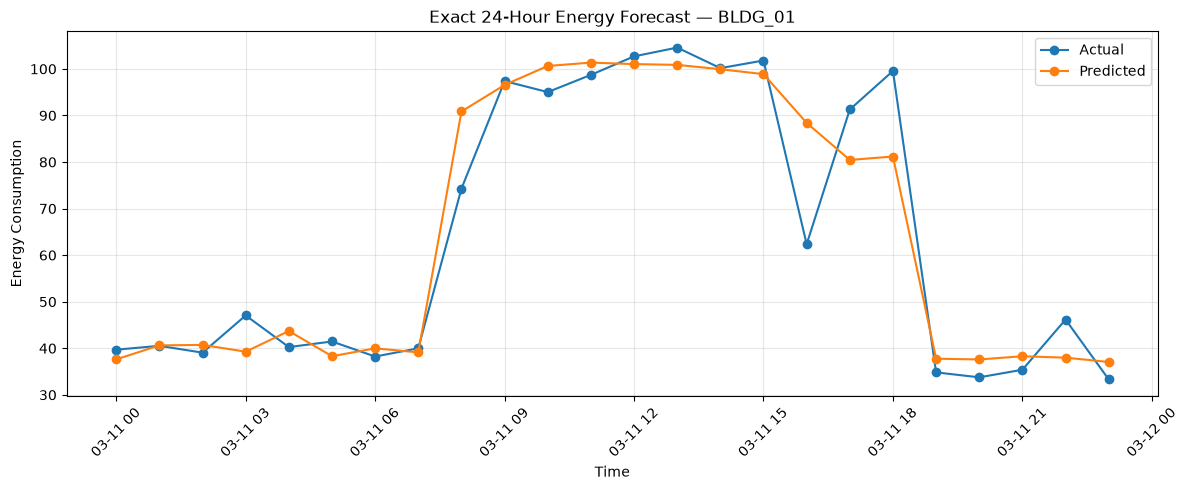

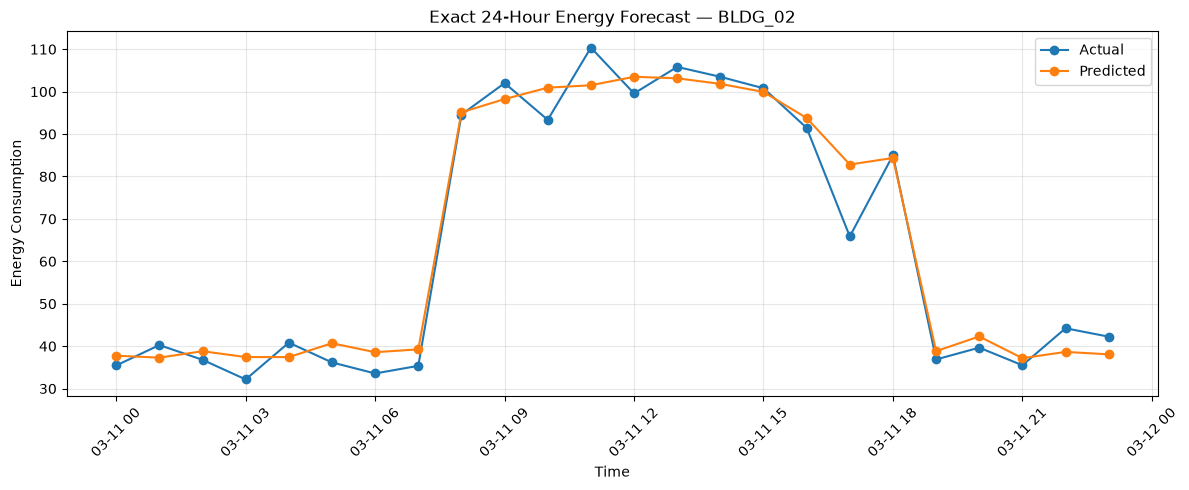

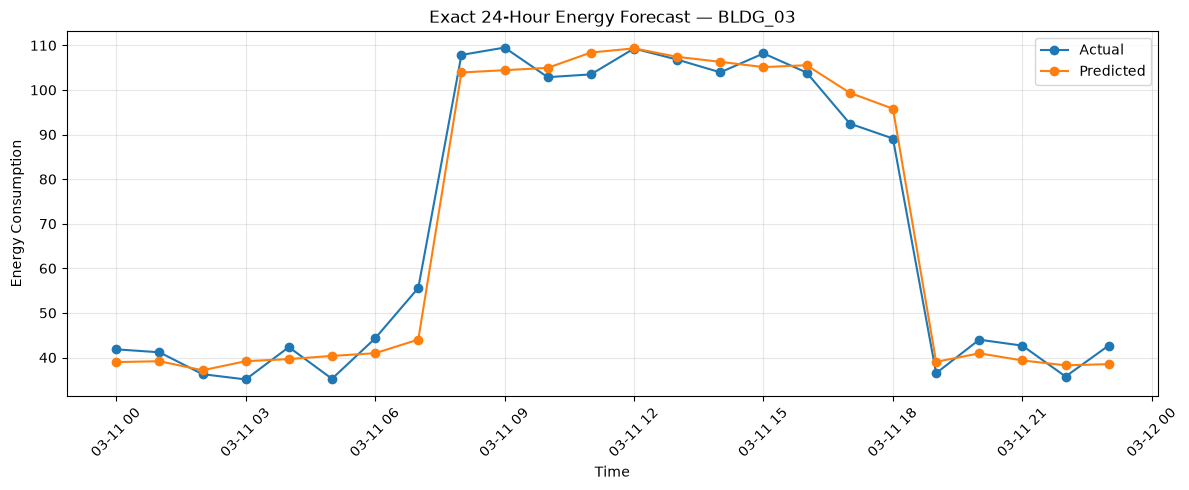

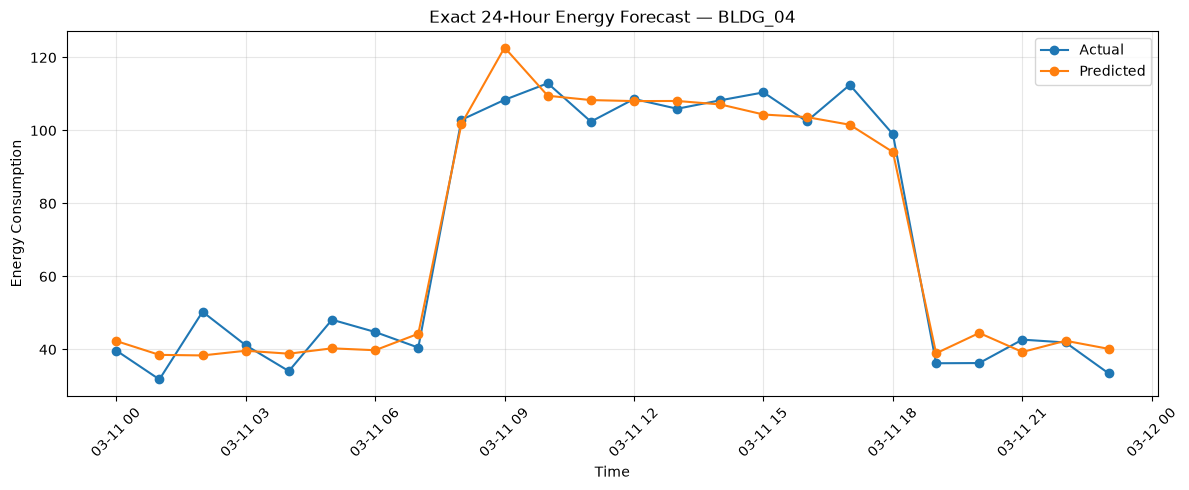

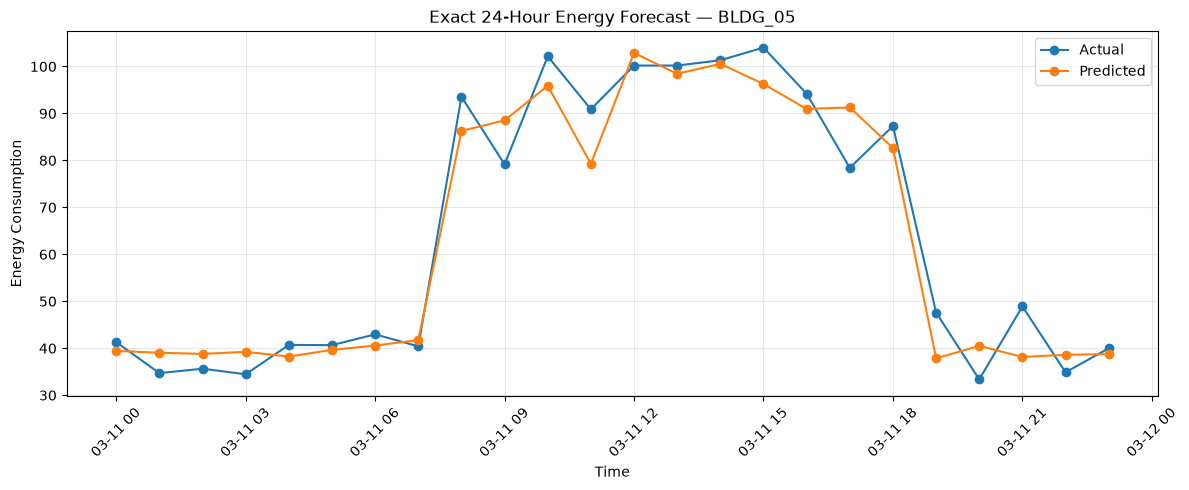

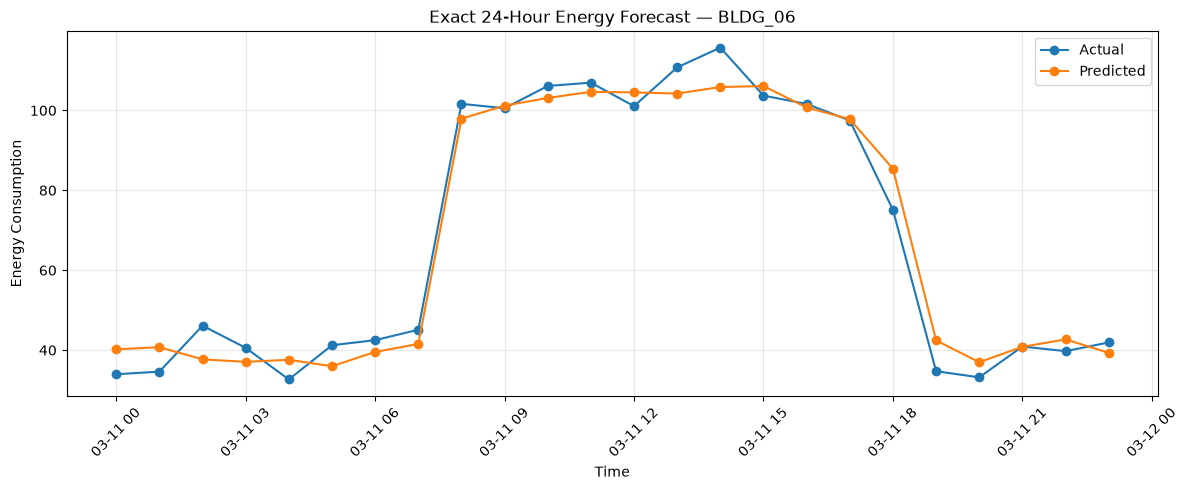

In [25]:
# Plot exact 24-hour actual vs predicted energy for each building

for building in sorted(exact_24h_predictions["building_id"].unique()):

    temp = exact_24h_predictions[
        exact_24h_predictions["building_id"] == building
    ].sort_values("timestamp")

    plt.figure(figsize=(12, 5))

    plt.plot(
        temp["timestamp"],
        temp["actual"],
        marker="o",
        label="Actual"
    )

    plt.plot(
        temp["timestamp"],
        temp["predicted"],
        marker="o",
        label="Predicted"
    )

    plt.title(
        f"Exact 24-Hour Energy Forecast — {building}"
    )
    plt.xlabel("Time")
    plt.ylabel("Energy Consumption")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 13.4 Interpretation

This exact 24-hour evaluation directly addresses the challenge requirement. The earlier 21-day holdout remains useful because it tests how the recursive model behaves over a longer unseen period. The two evaluations answer different questions and should both be reported.

> **Resolution note:** The source telemetry is recorded every 15 minutes, but the computationally practical XGBoost/SARIMA/LSTM forecasting pipeline in this notebook operates at hourly resolution. Therefore, the strict 24-hour evaluation consists of 24 hourly predictions.

# 14. Business Insights

After evaluating the models, report findings in this format:

### Forecasting
- Identify the model with the lowest overall forecasting error.
- Compare performance across buildings.
- Identify buildings with higher forecast uncertainty/error.

### Energy optimization
- Identify high-consumption periods.
- Compare weekday and weekend patterns.
- Relate energy demand to occupancy and temperature where supported by the data.

### Operational use
The forecast can support:
- proactive HVAC scheduling
- peak-load preparation
- energy optimization
- abnormal consumption investigation
- maintenance/energy coordination

### Limitations
- The challenge dataset is synthetic.
- Forecast accuracy on real buildings may differ.
- Future occupancy/weather information is not necessarily known.
- MAPE can become unstable when actual consumption is close to zero.
- Model performance should be revalidated after deployment on real telemetry.

In [26]:
# 14. Save Energy Forecasting Artifacts for the Dashboard

import joblib
import json

MODEL_DIR = OUTPUTS_DIR / "models" / "energy_forecasting"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save all building-specific XGBoost models.
joblib.dump(
    xgb_models,
    MODEL_DIR / "xgboost_energy_models.joblib"
)

energy_model_config = {
    "model": "XGBoost",
    "frequency": "1h",
    "forecast_horizon_hours": 24,
    "feature_columns": list(feature_columns),
    "buildings": sorted(list(xgb_models.keys())),
    "seed": SEED
}

with open(MODEL_DIR / "model_config.json", "w", encoding="utf-8") as f:
    json.dump(energy_model_config, f, indent=2)

# Save the exact 24-hour evaluation used in the notebook.
exact_24h_results.to_csv(
    MODEL_DIR / "exact_24h_results.csv",
    index=False
)

exact_24h_predictions.to_csv(
    MODEL_DIR / "exact_24h_predictions.csv",
    index=False
)

model_comparison.to_csv(
    MODEL_DIR / "model_comparison.csv"
)

print("Saved energy-forecasting artifacts to:", MODEL_DIR.resolve())

Saved energy-forecasting artifacts to: C:\Users\priya\OneDrive\Documents\sem 10 INTERN\Challenge\Nectar Task\outputs\models\energy_forecasting
